# Crisiss MMD

## Text Preprocessing

In [41]:
# Import library
import os
import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
import string
import re

### Load Data

In [42]:
text = pd.read_csv("CrisisMMD_v2.0/annotations/mexico_earthquake_final_data.tsv", 
                  sep = "\t")

In [43]:
text.head()

,tweet_id,image_id,text_info,text_info_conf,image_info,image_info_conf,text_human,text_human_conf,image_human,image_human_conf,image_damage,image_damage_conf,tweet_text,image_url,image_path
0,910523364154003456,910523364154003456_0,not_informative,1.0000,not_informative,1.0000,not_humanitarian,1.0000,not_humanitarian,1.0000,NaN,NaN,RT @FCBarcelona: Our solidarity with the victi...,http://pbs.twimg.com/media/DKLLdbyW0AASG2R.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
1,910523388598280192,910523388598280192_0,informative,1.0000,informative,0.6720,injured_or_dead_people,1.0000,infrastructure_and_utility_damage,0.6720,dont_know_or_cant_judge,0.4174,Mexico earthquake: Many children killed at pri...,http://pbs.twimg.com/media/DKLUMbJV4AACuFU.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
2,910523397448314882,910523397448314882_0,not_informative,0.6643,not_informative,1.0000,not_humanitarian,0.6643,not_humanitarian,1.0000,NaN,NaN,Obamaâ€™s Response To The Earthquake In #Mexic...,http://pbs.twimg.com/media/DKLUND8WAAAHgON.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
3,910523398144397312,910523398144397312_0,informative,0.9282,informative,1.0000,rescue_volunteering_or_donation_effort,0.9282,rescue_volunteering_or_donation_effort,1.0000,NaN,NaN,RT @AmichaiStein1: #BREAKING: Israel search &a...,http://pbs.twimg.com/media/DKK1CuDWsAAX5Vk.jpg,data_image/mexico_earthquake/20_9_2017/9105233...
4,910523398144397312,910523398144397312_1,informative,0.9282,informative,0.6943,rescue_volunteering_or_donation_effort,0.9282,rescue_volunteering_or_donation_effort,0.6943,NaN,NaN,RT @AmichaiStein1: #BREAKING: Israel search &a...,http://pbs.twimg.com/media/DKK1DyDXkAABvBX.jpg,data_image/mexico_earthquake/20_9_2017/9105233...


In [44]:
text.isna().sum()

tweet_id                0
image_id                0
text_info               0
text_info_conf          0
image_info              0
image_info_conf         0
text_human              0
text_human_conf         0
image_human             0
image_human_conf        0
image_damage         1198
image_damage_conf    1198
tweet_text              0
image_url               0
image_path              0
dtype: int64

In [45]:
text['tweet_text'].tolist()

['RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB',
 'Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758',
 'Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf',
 'RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx',
 'RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx',
 'RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx',
 'NEWS: At least 200 people, including 21 children, have died in Mexico after an earthquake hit the country. https://t.co/Wzp6DSKdTs',
 'RT @TravelLeisure: Deadly earthquake shakes Mexico City, causes buildings to crumble https://t.co/Ad7BYyR1b

### Konfig

In [46]:
# Ambil 5 tweet pertama sebagai contoh sebelum preprocessing
sample_indices = [0, 1, 2, 3, 4]
original_samples = [str(text['tweet_text'].iloc[i]) for i in sample_indices]

### Lowercase

In [47]:
# Lowercasing
text["tweet_text"] = text["tweet_text"].apply(lambda x: str(x).lower())

after_step1 = [str(text['tweet_text'].iloc[i]) for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step1[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt @fcbarcelona: our solidarity with the victims of the earthquake in mexico https://t.co/4r52ktn7cb
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school https://t.co/h0upkn13mh https://t.co/0vga5lj758
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€™s response to the earthquake in #mexicocity is what a real #president #soundslike... https://t.co/5efdmnugws https://t.co/itx4uvwgxf
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescu

### Hapus URL

In [48]:
text["tweet_text"] = text["tweet_text"].apply(
    lambda x: re.sub(r"http\S+|https\S+|www\.\S+", '', x)
)

after_step2 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step2[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt @fcbarcelona: our solidarity with the victims of the earthquake in mexico 
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school  
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€™s response to the earthquake in #mexicocity is what a real #president #soundslike...  
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx
Sesudah : rt @amichaistein1: #breaking: is

### Tag dan Mention

In [49]:
text["tweet_text"] = text["tweet_text"].apply(
    lambda x: re.sub(r'#|\@\w+', '', x) # hapus mention tapi tidak dengan tags
)

after_step3 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step3[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt : our solidarity with the victims of the earthquake in mexico 
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school  
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€™s response to the earthquake in mexicocity is what a real president soundslike...  
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx
Sesudah : rt : breaking: israel search &amp; rescue missi

### Hapus Emoji

In [50]:
import emoji
text["tweet_text"] = text["tweet_text"].apply(
    lambda x: emoji.replace_emoji(x, replace=' ')
)

after_step4 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step4[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt : our solidarity with the victims of the earthquake in mexico 
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school  
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€ s response to the earthquake in mexicocity is what a real president soundslike...  
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx
Sesudah : rt : breaking: israel search &amp; rescue missi

### Rapihkan Spasi

In [51]:
text["tweet_text"] = text["tweet_text"].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

after_step5 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step5[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt : our solidarity with the victims of the earthquake in mexico
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€ s response to the earthquake in mexicocity is what a real president soundslike...
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx
Sesudah : rt : breaking: israel search &amp; rescue mission he

### Menghapus Angka dan Satuan Angka

In [52]:
def remove_rank_size_and_time(x):
    x = str(x)
    # Hapus pola: 2nd
    x = re.sub(r'\b\d+\s*(st|nd|rd|th)\b', '', x, flags=re.I)
    # hapus pola 10k, 8k
    x = re.sub(r'\b\d+\s*(k|m)\b', '', x, flags = re.I)
    # Hapus pola waktu: 7 pm, 10 am, 7pm, 10am
    x = re.sub(r'\b\d+\s*(am|pm)\b', '', x, flags=re.I)
    # hapus angka
    x = re.sub(r'\d+', '', x, flags = re.I)
    return x

text['tweet_text'] = text['tweet_text'].apply(remove_rank_size_and_time)

after_step6 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step6[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt : our solidarity with the victims of the earthquake in mexico
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake: many children killed at primary school
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obamaâ€ s response to the earthquake in mexicocity is what a real president soundslike...
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx
Sesudah : rt : breaking: israel search &amp; rescue mission he

### Hapus Tanda Baca

In [53]:
import string

text['tweet_text'] = text['tweet_text'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

after_step7 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step7[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : rt  our solidarity with the victims of the earthquake in mexico
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake many children killed at primary school
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obama s response to the earthquake in mexicocity is what a real president soundslike
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx
Sesudah : rt  breaking israel search amp rescue mission headed to mex

### Hapus RT

In [54]:
text['tweet_text'] = text['tweet_text'].apply(
    lambda x: re.sub(r'\brt\b', '', x)
)

after_step8 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step8[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah :   our solidarity with the victims of the earthquake in mexico
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake many children killed at primary school
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obama s response to the earthquake in mexicocity is what a real president soundslike
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx
Sesudah :   breaking israel search amp rescue mission headed to mexico 

### Stopword

In [55]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def stopwords_tokens(text):
    tokens = [w for w in word_tokenize(text) if w not in stop_words]
    return ' '.join(tokens)

text['stopwords'] = text['tweet_text'].apply(stopwords_tokens)

after_step9 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step9[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah :   our solidarity with the victims of the earthquake in mexico
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake many children killed at primary school
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obama s response to the earthquake in mexicocity is what a real president soundslike
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx
Sesudah :   breaking israel search amp rescue mission headed to mexico 

### Function

In [56]:
# def clean_text(text):
    #if not isinstance(text, str):
        #return ''
    #text = text.lower()
    #text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    #text = re.sub(r'@\w+|#', '', text)
    #text = re.sub(r'\b\d+\s*(st|nd|rd|th)\b', '', text, flags=re.I)
    #text = re.sub(r'\b\d+\s*(k|m)\b', '', text, flags=re.I)
    #text = re.sub(r'\b\d+\s*(am|pm)\b', '', text, flags=re.I)
    #text = re.sub(r'\d+', '', text)
    #text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    #text = re.sub(r'\brt\b', '', text)
    #text = re.sub(r'\s+', ' ', text).strip()
    #tokens = [w for w in word_tokenize(text) if w not in stop_words]
    #return ' '.join(tokens)
#text['function'] = text['tweet_text'].apply(clean_text)

In [57]:
#text[['tweet_text', 'function']]

### Lemmatization

In [58]:
wnl = WordNetLemmatizer()
text["tweet_text"] = text["tweet_text"].apply(
    lambda x: " ".join([wnl.lemmatize(word, pos='v') for word in x.split()])
)

after_step10 = [text['tweet_text'].iloc[i] for i in sample_indices]
for i in range(len(sample_indices)):
    print(f"Sebelum: {original_samples[i]}")
    print(f"Sesudah : {after_step10[i]}")
    print("-" * 60)

Sebelum: RT @FCBarcelona: Our solidarity with the victims of the earthquake in Mexico https://t.co/4R52KTn7CB
Sesudah : our solidarity with the victims of the earthquake in mexico
------------------------------------------------------------
Sebelum: Mexico earthquake: Many children killed at primary school https://t.co/h0uPkN13mH https://t.co/0vGA5lj758
Sesudah : mexico earthquake many children kill at primary school
------------------------------------------------------------
Sebelum: Obamaâ€™s Response To The Earthquake In #MexicoCity Is What A Real #President #SoundsLike... https://t.co/5EFdMNUgWS https://t.co/ITx4uVwgxf
Sesudah : obama s response to the earthquake in mexicocity be what a real president soundslike
------------------------------------------------------------
Sebelum: RT @AmichaiStein1: #BREAKING: Israel search &amp; rescue mission headed to Mexico after 7.1M earthquake https://t.co/lSd0e5ZVdx
Sesudah : break israel search amp rescue mission head to mexico after earth

## Image Preprocessing

In [59]:
text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   tweet_id           1380 non-null   int64  
 1   image_id           1380 non-null   object 
 2   text_info          1380 non-null   object 
 3   text_info_conf     1380 non-null   float64
 4   image_info         1380 non-null   object 
 5   image_info_conf    1380 non-null   float64
 6   text_human         1380 non-null   object 
 7   text_human_conf    1380 non-null   float64
 8   image_human        1380 non-null   object 
 9   image_human_conf   1380 non-null   float64
 10  image_damage       182 non-null    object 
 11  image_damage_conf  182 non-null    float64
 12  tweet_text         1380 non-null   object 
 13  image_url          1380 non-null   object 
 14  image_path         1380 non-null   object 
 15  stopwords          1380 non-null   object 
dtypes: float64(5), int64(1),

In [60]:
# Import Library
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from PIL import Image
import imagehash
import warnings
warnings.filterwarnings('ignore') 

### Konfig

In [61]:
BASE_DIR = "CrisisMMD_v2.0"   # folder utama project
IMG_SIZE = (224, 224)         # (W, H) target image size
TH_INFO = 0.7                 # threshold confidence untuk label image_info
USE_IMAGENET_NORM = True      # normalisasi dengan statistik ImageNet

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

print("Konfigurasi Task A:")
print("IMG_SIZE:", IMG_SIZE)
print("TH_INFO:", TH_INFO)
print("USE_IMAGENET_NORM:", USE_IMAGENET_NORM)

Konfigurasi Task A:
IMG_SIZE: (224, 224)
TH_INFO: 0.7
USE_IMAGENET_NORM: True


### Load Data

In [62]:
df = text.copy()   # jadikan salinan dataframe text

print("Shape df (dari preprocessing teks):", df.shape)
print("Kolom-kolom yang ada:", df.columns.tolist())

print("\nContoh image_path mentah:")
print(df["image_path"].head())

# Ambil hanya baris yang punya image_path
df_img = df[~df["image_path"].isna()].copy()

# Bangun full_path ke file gambar
def make_full_path(rel_path):
    rel_path = str(rel_path).lstrip("/\\")  # buang leading slash/backslash
    return os.path.normpath(os.path.join(BASE_DIR, rel_path))

df_img["full_path"] = df_img["image_path"].apply(make_full_path)

print("\nContoh full_path:")
print(df_img[["image_id", "image_path", "full_path"]].head())

Shape df (dari preprocessing teks): (1380, 16)
Kolom-kolom yang ada: ['tweet_id', 'image_id', 'text_info', 'text_info_conf', 'image_info', 'image_info_conf', 'text_human', 'text_human_conf', 'image_human', 'image_human_conf', 'image_damage', 'image_damage_conf', 'tweet_text', 'image_url', 'image_path', 'stopwords']

Contoh image_path mentah:
0    data_image/mexico_earthquake/20_9_2017/9105233...
1    data_image/mexico_earthquake/20_9_2017/9105233...
2    data_image/mexico_earthquake/20_9_2017/9105233...
3    data_image/mexico_earthquake/20_9_2017/9105233...
4    data_image/mexico_earthquake/20_9_2017/9105233...
Name: image_path, dtype: object

Contoh full_path:
               image_id  ...                                          full_path
0  910523364154003456_0  ...  CrisisMMD_v2.0\data_image\mexico_earthquake\20...
1  910523388598280192_0  ...  CrisisMMD_v2.0\data_image\mexico_earthquake\20...
2  910523397448314882_0  ...  CrisisMMD_v2.0\data_image\mexico_earthquake\20...
3  9105233

### Preprocessing

In [63]:
# syarat: punya label image_info dan confidence >= TH_INFO
mask_label = df_img["image_info"].notna()
mask_conf  = df_img["image_info_conf"].notna() & (df_img["image_info_conf"] >= TH_INFO)

df_taskA = df_img[mask_label & mask_conf].copy()
df_taskA.reset_index(drop=True, inplace=True)

print("\nJumlah baris setelah filter label+confidence:", df_taskA.shape[0])
print("Distribusi label image_info:")
print(df_taskA["image_info"].value_counts())


Jumlah baris setelah filter label+confidence: 848
Distribusi label image_info:
image_info
informative        471
not_informative    377
Name: count, dtype: int64


In [64]:
# cek keberadaan file
df_taskA["exists"] = df_taskA["full_path"].apply(os.path.exists)
missing_files = df_taskA[~df_taskA["exists"]]

print("\nJumlah file gambar yang tidak ditemukan:", len(missing_files))
if len(missing_files) > 0:
    print(missing_files[["image_id", "full_path"]].head())

df_taskA = df_taskA[df_taskA["exists"]].copy()
df_taskA.reset_index(drop=True, inplace=True)
print("Jumlah baris setelah buang file yang tidak ada:", df_taskA.shape[0])


Jumlah file gambar yang tidak ditemukan: 0
Jumlah baris setelah buang file yang tidak ada: 848


In [65]:
# Cek duplikasi gambar
def compute_phash(path):
    try:
        img = Image.open(path).convert("RGB")
        return imagehash.phash(img)
    except Exception as e:
        print("Gagal hitung pHash:", path, "->", e)
        return None

df_taskA["phash"] = df_taskA["full_path"].apply(compute_phash)
before_phash = len(df_taskA)
df_taskA = df_taskA[df_taskA["phash"].notna()].copy()
print(f"\nSetelah buang yang gagal di-phash: {len(df_taskA)} (dari {before_phash})")

# untuk dedup, urutkan dulu berdasarkan confidence (biar yg konf-nya tinggi dipertahankan)
df_taskA = df_taskA.sort_values("image_info_conf", ascending=False)

# drop duplikat berdasarkan pHash (satu hash dianggap satu konten gambar)
df_taskA = df_taskA.drop_duplicates(subset="phash", keep="first").reset_index(drop=True)

print("Jumlah baris setelah deduplikasi pHash:", len(df_taskA))



Setelah buang yang gagal di-phash: 848 (dari 848)
Jumlah baris setelah deduplikasi pHash: 806


In [66]:
# Encode label image_info 

# Misal nilai unik: ["informative", "not_informative"]
# Tapi biar umum, kita buat mapping otomatis

unique_labels = sorted(df_taskA["image_info"].unique())
label2id = {lab: i for i, lab in enumerate(unique_labels)}
print("\nMapping label2id:", label2id)

df_taskA["image_info_id"] = df_taskA["image_info"].map(label2id)
y_info = df_taskA["image_info_id"].values


Mapping label2id: {'informative': 0, 'not_informative': 1}


In [67]:
# Fungsi LetterBox Resize (mempertahankan aspek ratio)

def letterbox_resize(img_rgb, target_size):
    """
    Resize dengan mempertahankan aspect ratio.
    Sisi terpanjang diset ke target, sisi lain dipadding (hitam).
    """
    target_w, target_h = target_size
    h, w = img_rgb.shape[:2]

    # scale factor
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # resize
    resized = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # buat canvas hitam
    canvas = np.zeros((target_h, target_w, 3), dtype=np.uint8)

    # posisi tengah
    top = (target_h - new_h) // 2
    left = (target_w - new_w) // 2
    canvas[top:top+new_h, left:left+new_w, :] = resized

    return canvas


In [68]:
def preprocess_image_cv2(path, img_size=IMG_SIZE, debug=False):
    """
    1. read BGR / grayscale
    2. konversi ke RGB 3-channel
    3. letterbox resize ke img_size
    4. normalisasi ke [0,1]
    5. opsional: normalisasi ImageNet mean/std
    """
    debug_imgs = {}

    # load gambar apa adanya
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        print("Gagal load:", path)
        return None if not debug else (None, None)

    # handle grayscale -> BGR
    if len(img.shape) == 2 or (len(img.shape) == 3 and img.shape[2] == 1):
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    debug_imgs["bgr_raw"] = img.copy()

    # BGR -> RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    debug_imgs["rgb"] = img_rgb.copy()

    # letterbox resize
    img_lb = letterbox_resize(img_rgb, img_size)
    debug_imgs["letterbox"] = img_lb.copy()

    # scale ke [0,1]
    img_float = img_lb.astype(np.float32) / 255.0

    # normalisasi ImageNet (opsional)
    if USE_IMAGENET_NORM:
        img_norm = (img_float - IMAGENET_MEAN) / IMAGENET_STD
    else:
        img_norm = img_float

    debug_imgs["normalized"] = img_norm.copy()

    if debug:
        return img_norm, debug_imgs
    else:
        return img_norm

In [69]:
# Output image process
def show_debug_steps(debug_imgs, title_prefix=""):
    plt.figure(figsize=(12, 6))

    # BGR raw
    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(debug_imgs["bgr_raw"], cv2.COLOR_BGR2RGB))
    plt.title(f"{title_prefix} - BGR Raw")
    plt.axis("off")

    # RGB
    plt.subplot(2, 2, 2)
    plt.imshow(debug_imgs["rgb"])
    plt.title(f"{title_prefix} - RGB")
    plt.axis("off")

    # Letterbox resized
    plt.subplot(2, 2, 3)
    plt.imshow(debug_imgs["letterbox"])
    plt.title(f"{title_prefix} - Letterbox {IMG_SIZE}")
    plt.axis("off")

    # Normalized (ditampilkan dengan "un-normalize" agar terlihat wajar)
    plt.subplot(2, 2, 4)
    img_disp = debug_imgs["normalized"]
    if USE_IMAGENET_NORM:
        img_disp = img_disp * IMAGENET_STD + IMAGENET_MEAN
    img_disp = np.clip(img_disp, 0, 1)
    plt.imshow(img_disp)
    vmin = debug_imgs["normalized"].min()
    vmax = debug_imgs["normalized"].max()
    plt.title(f"{title_prefix} - Normalized\nmin={vmin:.3f}, max={vmax:.3f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()



=== DEMO PREPROCESSING GAMBAR 0 (label: informative) ===
Path: CrisisMMD_v2.0\data_image\mexico_earthquake\3_10_2017\915201277432418305_0.jpg
Shape setelah preprocessing: (224, 224, 3)
Range nilai: -2.117904 sampai 2.64


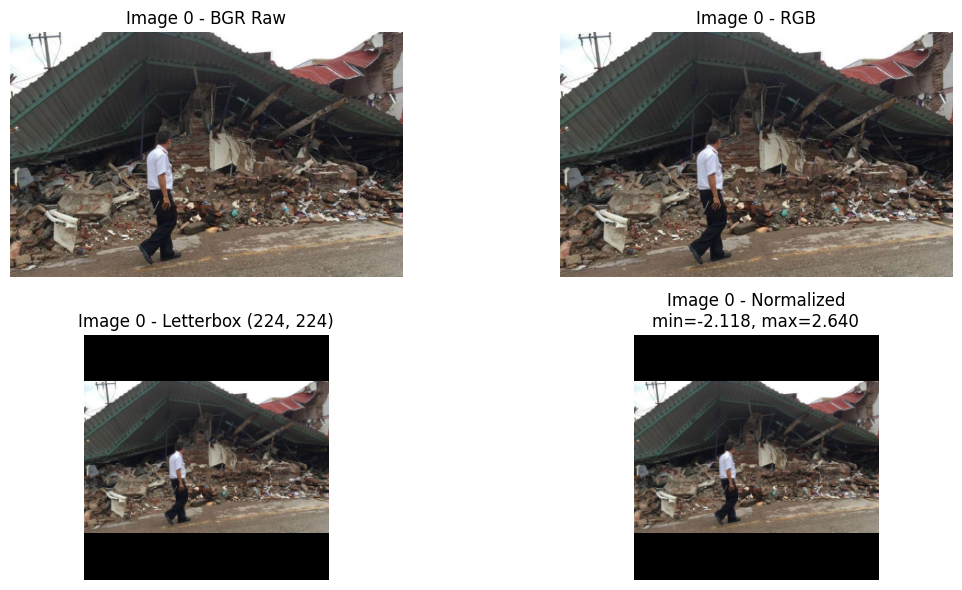


=== DEMO PREPROCESSING GAMBAR 1 (label: informative) ===
Path: CrisisMMD_v2.0\data_image\mexico_earthquake\3_10_2017\915179664385208320_0.jpg
Shape setelah preprocessing: (224, 224, 3)
Range nilai: -2.117904 sampai 2.64


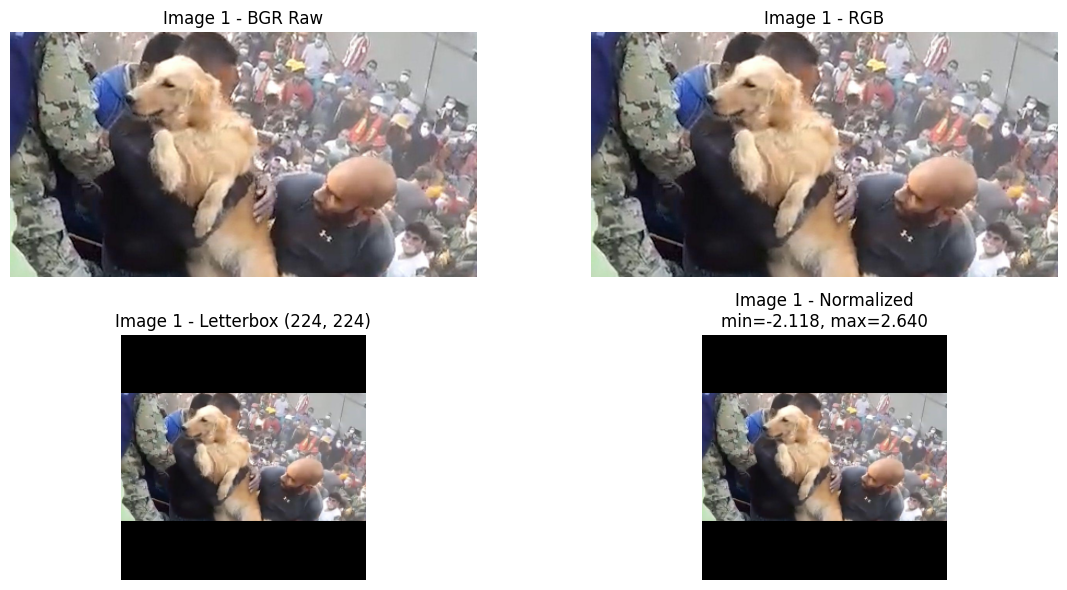


=== DEMO PREPROCESSING GAMBAR 2 (label: not_informative) ===
Path: CrisisMMD_v2.0\data_image\mexico_earthquake\3_10_2017\915167299610521601_0.jpg
Shape setelah preprocessing: (224, 224, 3)
Range nilai: -2.117904 sampai 2.64


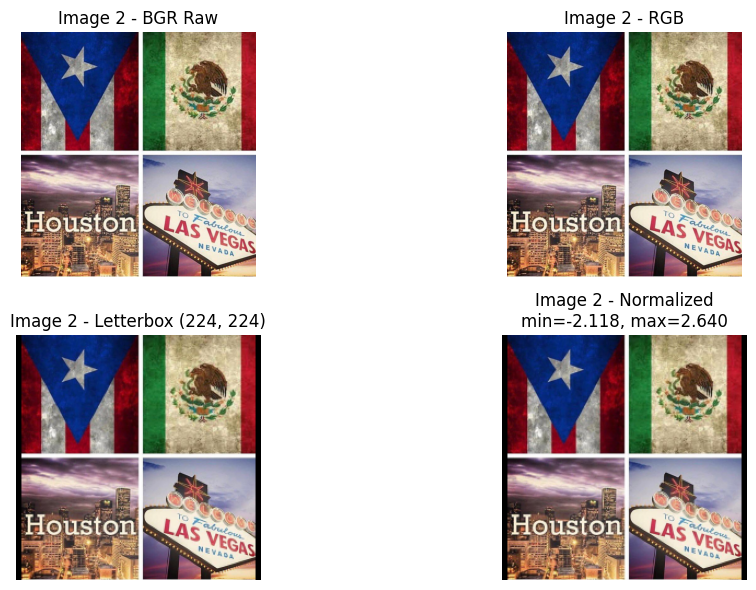


=== DEMO PREPROCESSING GAMBAR 3 (label: not_informative) ===
Path: CrisisMMD_v2.0\data_image\mexico_earthquake\3_10_2017\915140840279875584_0.jpg
Shape setelah preprocessing: (224, 224, 3)
Range nilai: -2.117904 sampai 2.64


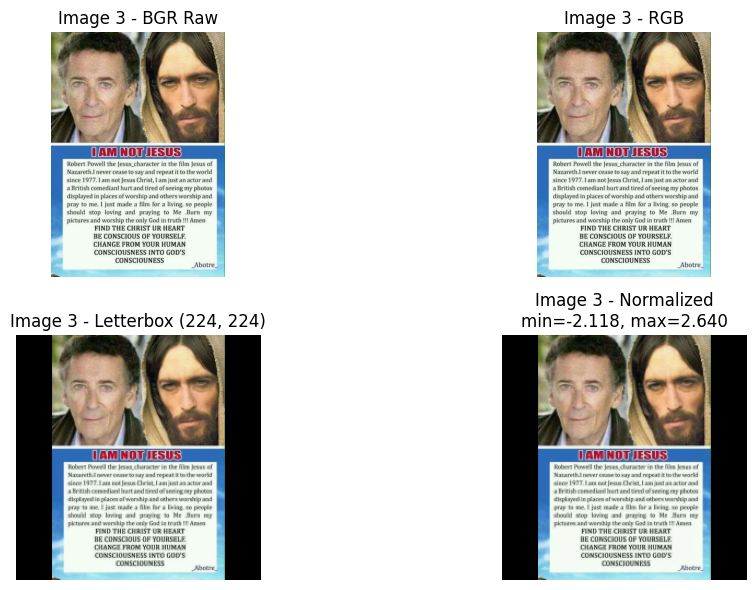


=== DEMO PREPROCESSING GAMBAR 4 (label: not_informative) ===
Path: CrisisMMD_v2.0\data_image\mexico_earthquake\3_10_2017\915132657280929792_0.jpg
Shape setelah preprocessing: (224, 224, 3)
Range nilai: -2.117904 sampai 2.64


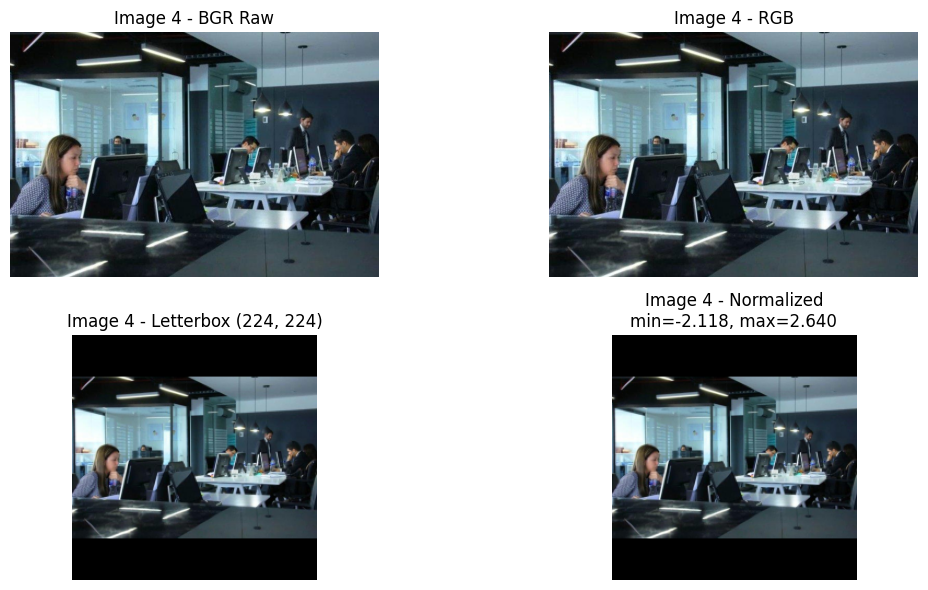

In [70]:
n_demo = min(5, len(df_taskA))
for i in range(n_demo):
    sample_path = df_taskA.loc[i, "full_path"]
    sample_label = df_taskA.loc[i, "image_info"]
    print(f"\n=== DEMO PREPROCESSING GAMBAR {i} (label: {sample_label}) ===")
    print("Path:", sample_path)
    img_norm, dbg = preprocess_image_cv2(sample_path, debug=True)
    if img_norm is None:
        continue
    print("Shape setelah preprocessing:", img_norm.shape)
    print("Range nilai:", img_norm.min(), "sampai", img_norm.max())
    show_debug_steps(dbg, title_prefix=f"Image {i}")


In [71]:
# Preprocess semua gambar 

all_images = []
valid_indices = []

for idx, row in tqdm(df_taskA.iterrows(),
                     total=len(df_taskA),
                     desc="Preprocessing image Task A"):
    img_array = preprocess_image_cv2(row["full_path"], debug=False)
    if img_array is not None:
        all_images.append(img_array)
        valid_indices.append(idx)

if len(all_images) == 0:
    raise RuntimeError("Tidak ada gambar yang berhasil diproses untuk Task A.")

X_images = np.stack(all_images, axis=0)
df_taskA_clean = df_taskA.loc[valid_indices].reset_index(drop=True)
y_info = df_taskA_clean["image_info_id"].values

print("\n=== RINGKASAN AKHIR TASK A ===")
print("Shape X_images:", X_images.shape)
print("Pixel range:", X_images.min(), "sampai", X_images.max())
print("Shape y_info:", y_info.shape)
print("Mapping label2id:", label2id)

Preprocessing image Task A: 100%|██████████| 806/806 [00:08<00:00, 98.75it/s] 



=== RINGKASAN AKHIR TASK A ===
Shape X_images: (806, 224, 224, 3)
Pixel range: -2.117904 sampai 2.64
Shape y_info: (806,)
Mapping label2id: {'informative': 0, 'not_informative': 1}
